In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

print(device)

cuda


In [2]:

import torch.nn.functional as F

def ssim3d(a, b, window=4):
    a = (a + 1) / 2
    b = (b + 1) / 2
    stride = window

    mu_a = F.avg_pool3d(a, window, stride)
    mu_b = F.avg_pool3d(b, window, stride)
    mu_a2, mu_b2, mu_ab = mu_a * mu_a, mu_b * mu_b, mu_a * mu_b

    var_a = F.avg_pool3d(a * a, window, stride) - mu_a2
    var_b = F.avg_pool3d(b * b, window, stride) - mu_b2
    cov   = F.avg_pool3d(a * b, window, stride) - mu_ab

    C1, C2 = 0.01 ** 2, 0.03 ** 2
    num = (2 * mu_ab + C1) * (2 * cov + C2)
    den = (mu_a2 + mu_b2 + C1) * (var_a + var_b + C2)
    return (num / den).mean()

class BlurFixLoss(nn.Module):
    def __init__(self, alpha=0.81):
        super().__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()

    def forward(self, out, target):
        return self.alpha * self.mse(out, target) + (1 - self.alpha) * (1 - ssim3d(out, target))

In [3]:
#adjustable parameters
from AutoEncoder import AutoEncoder

epochs = 15
lr = 1e-4
latent_dim = 8192
batch_size = 8


model = AutoEncoder(latent_dim=latent_dim).to(device)
full_dataset = "C:\\Users\\Mike\\Desktop\\PC_ONLY_3DOCT\\data"
criterion = BlurFixLoss(alpha=0.6).to(device)
#criterion = BlurFixLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
#id use this but its in a zip so i cant access it without putting 600gb of images on my pc
#from datasets import load_dataset
#dataset = load_dataset("harvardairobotics/FairVision", streaming=True)

In [4]:
from OCT3D_DataLoader import load_oct_loader

train_loader = load_oct_loader("Training", batch_size, shuffle=True)
val_loader = load_oct_loader("Validation", batch_size, shuffle=False)
test_loader = load_oct_loader("Test", batch_size, shuffle=False)

In [5]:
#Training Loop
scaler = torch.amp.GradScaler(device.type)

pretrained_train_losses = []
pretrained_val_losses = []


for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, *_ in train_loader:
        #tanh
        images = images.to(device, non_blocking=True).float().div_(127.5).sub_(1.0)


        optimizer.zero_grad()

        with torch.amp.autocast(device_type=device.type):
            outputs = model(images)

        # fp32 - SSIM underflows in half precision
        loss = criterion(outputs.float(), images)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
    pretrained_train_losses.append(total_loss / len(train_loader))


    #val
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, *_ in val_loader:
            images = images.to(device, non_blocking=True).float().div_(127.5).sub_(1.0)

            with torch.amp.autocast(device_type=device.type):
                outputs = model(images)
            val_loss += criterion(outputs.float(), images).item()

    epoch_val_loss = val_loss / len(val_loader)
    pretrained_val_losses.append(epoch_val_loss)

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Train: {avg_loss:.4f}, Val: {epoch_val_loss:.4f}, Scale: {scaler.get_scale():.0f}')

Epoch [1/15], Train: 0.4704, Val: 0.3600, Scale: 32768
Epoch [2/15], Train: 0.3375, Val: 0.3233, Scale: 32768
Epoch [3/15], Train: 0.3230, Val: 0.3181, Scale: 32768
Epoch [4/15], Train: 0.3192, Val: 0.3151, Scale: 32768
Epoch [5/15], Train: 0.3158, Val: 0.3119, Scale: 32768
Epoch [6/15], Train: 0.3124, Val: 0.3091, Scale: 32768
Epoch [7/15], Train: 0.3093, Val: 0.3067, Scale: 32768
Epoch [8/15], Train: 0.3070, Val: 0.3059, Scale: 65536
Epoch [9/15], Train: 0.3045, Val: 0.3030, Scale: 65536
Epoch [10/15], Train: 0.3025, Val: 0.3012, Scale: 65536
Epoch [11/15], Train: 0.3008, Val: 0.2998, Scale: 65536
Epoch [12/15], Train: 0.2993, Val: 0.2988, Scale: 65536
Epoch [13/15], Train: 0.2979, Val: 0.2989, Scale: 65536
Epoch [14/15], Train: 0.2974, Val: 0.2979, Scale: 65536
Epoch [15/15], Train: 0.2961, Val: 0.2968, Scale: 65536


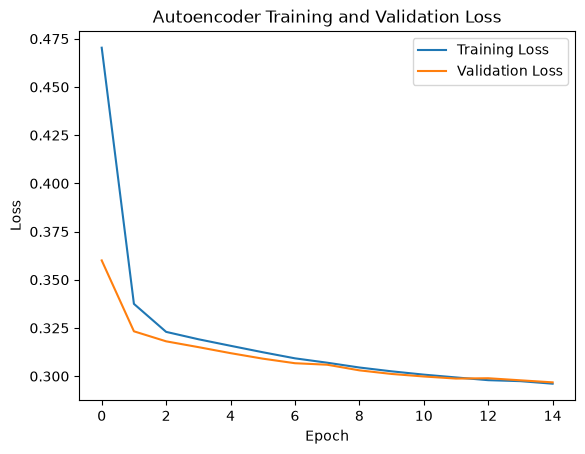

: 

In [ ]:
plt.plot(pretrained_train_losses, label="Training Loss")
plt.plot(pretrained_val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.show()

In [10]:
torch.save(model.state_dict(), "models\\3d_oct_autoencoder_modelSSIM.pth")
#only need the encoder part of the autoencoder for classifiers\
torch.save(model.encoder.state_dict(), "models\\3d_oct_encoderSSIM.pth")

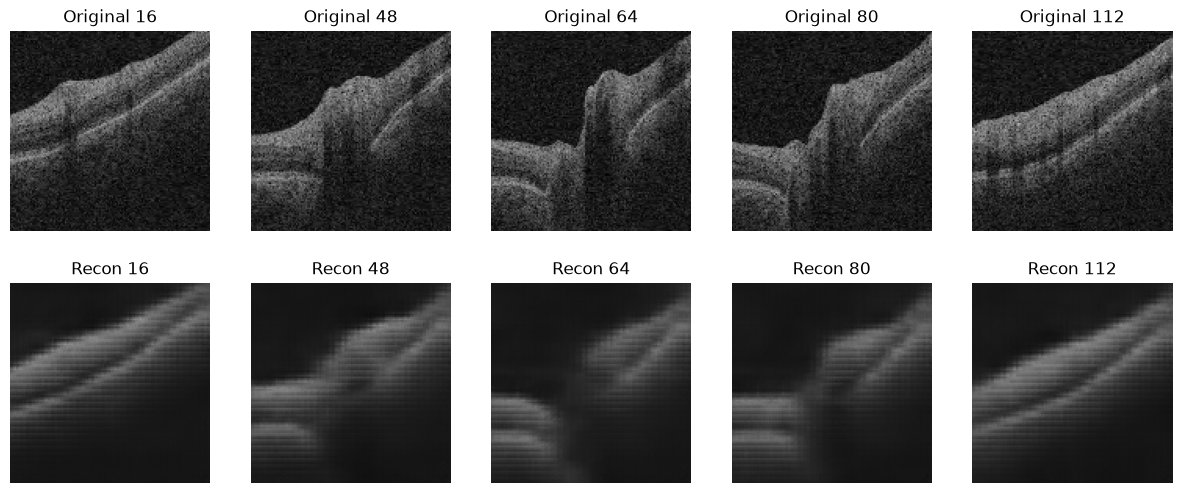

In [7]:
#model = AutoEncoder(latent_dim=latent_dim).to(device)
#model.load_state_dict(torch.load("models\\3d_oct_autoencoder_modelSSIM.pth", map_location=device))
model.eval()

images, *_ = next(iter(test_loader))
images = images.to(device, non_blocking=True).float().div_(127.5).sub_(1.0)

with torch.no_grad():
    output = model(images)

original = images[0, 0].cpu().numpy()
reconstructed = output[0, 0].cpu().numpy()

# convert [-1, 1] back to [0, 1]
original = (original + 1) / 2
reconstructed = (reconstructed + 1) / 2

slices = [16, 48, 64, 80, 112]
fig, axes = plt.subplots(2, len(slices), figsize=(15, 6))
for col, s in enumerate(slices):
    axes[0, col].imshow(original[s], cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"Original {s}")
    axes[0, col].axis("off")
    axes[1, col].imshow(reconstructed[s], cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title(f"Recon {s}")
    axes[1, col].axis("off")
plt.show()

In [8]:
#test
model.eval()
total_loss = 0

with torch.no_grad():
    for images, *_ in test_loader:
        images = images.to(device, non_blocking=True).float().div_(127.5).sub_(1.0)
        reconstructions = model(images)
        total_loss += criterion(reconstructions.float(), images).item()

print("avg_loss", total_loss / len(test_loader))

avg_loss 0.2969900504150222


subject 0: vs own 0.0281   vs other 0.0855
subject 1: vs own 0.0221   vs other 0.1136
subject 2: vs own 0.0239   vs other 0.1066


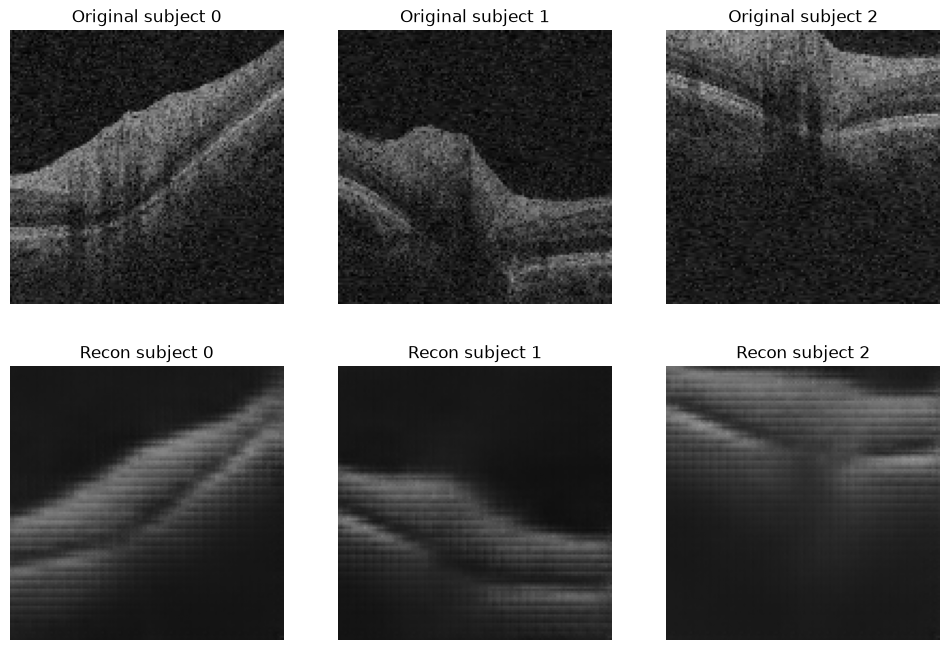

In [9]:
model.eval()

batch = torch.stack([test_loader.dataset[k][0] for k in range(3)]).to(device).float().div_(127.5).sub_(1.0)

with torch.no_grad():
    out = model(batch)

for k in range(3):
    own = ((out[k] - batch[k]) ** 2).mean().item()
    other = ((out[k] - batch[(k + 1) % 3]) ** 2).mean().item()
    print(f"subject {k}: vs own {own:.4f}   vs other {other:.4f}")

s = 100
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for k in range(3):
    axes[0, k].imshow((batch[k, 0, s].cpu().numpy() + 1) / 2, cmap="gray", vmin=0, vmax=1)
    axes[0, k].set_title(f"Original subject {k}")
    axes[0, k].axis("off")
    axes[1, k].imshow((out[k, 0, s].cpu().numpy() + 1) / 2, cmap="gray", vmin=0, vmax=1)
    axes[1, k].set_title(f"Recon subject {k}")
    axes[1, k].axis("off")
plt.show()